In [2]:
import cv2
import time
from insightface.app import FaceAnalysis
from matplotlib import pyplot as plt

## Insightface 모델 로드

In [3]:
app = FaceAnalysis(
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

## AdaFace 모델 로드

In [4]:
import os

print("현재 위치:")
print(os.getcwd())

print("\n현재 폴더 목록:")
for x in os.listdir("."):
    print(x)

현재 위치:
C:\Users\wonbin\Desktop\face-test\notebook

현재 폴더 목록:
.ipynb_checkpoints
adaface
auraface
embeddingTest.ipynb
insightface-detection.ipynb
yolov8n.ipynb


In [5]:
import os
import sys

if not os.path.exists("./adaface"):
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="minchul/cvlface_adaface_ir50_webface4m",
        local_dir="./adaface"
    )
sys.path.append("./adaface")

In [6]:
from omegaconf import OmegaConf
from models import get_model

conf = OmegaConf.load(
    "./adaface/pretrained_model/model.yaml"
)

for root, dirs, files in os.walk("./adaface"):
    for file in files:
        if file.endswith(".pt") or file.endswith(".ckpt") or file.endswith(".pth"):
            print(os.path.join(root, file))

print(conf)
model = get_model(conf)

./adaface\pretrained_model\model.pt
{'input_size': [3, 112, 112], 'color_space': 'RGB', 'name': 'ir50', 'output_dim': 512, 'start_from': '', 'freeze': False, 'yaml_path': 'models/iresnet/configs/v1_ir50.yaml'}
Loaded iResNet model


In [7]:
import torch

state_dict = torch.load(
    "./adaface/pretrained_model/model.pt",
    map_location="cpu"
)

msg = model.load_state_dict(
    state_dict,
    strict=False
)

print(msg)

<All keys matched successfully>


## AuraFace 다운로드

In [8]:
if not os.path.exists("./auraface"):
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="fal/AuraFace-v1",
        local_dir="./auraface"
    )
sys.path.append("./auraface")

In [9]:
for root, dirs, files in os.walk("./auraface"):
    for file in files:
        print(os.path.join(root, file))

./auraface\.gitattributes
./auraface\1k3d68.onnx
./auraface\2d106det.onnx
./auraface\genderage.onnx
./auraface\glintr100.onnx
./auraface\LICENSE.md
./auraface\README.md
./auraface\scrfd_10g_bnkps.onnx
./auraface\.cache\huggingface\.gitignore
./auraface\.cache\huggingface\CACHEDIR.TAG
./auraface\.cache\huggingface\download\.gitattributes.metadata
./auraface\.cache\huggingface\download\1k3d68.onnx.metadata
./auraface\.cache\huggingface\download\2d106det.onnx.metadata
./auraface\.cache\huggingface\download\genderage.onnx.metadata
./auraface\.cache\huggingface\download\glintr100.onnx.metadata
./auraface\.cache\huggingface\download\LICENSE.md.metadata
./auraface\.cache\huggingface\download\README.md.metadata
./auraface\.cache\huggingface\download\scrfd_10g_bnkps.onnx.metadata


In [10]:
import onnxruntime as ort

aura_session = ort.InferenceSession(
    "./auraface/glintr100.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = aura_session.get_inputs()[0].name
output_name = aura_session.get_outputs()[0].name

print(input_name)
print(output_name)

print("INPUT")
for inp in aura_session.get_inputs():
    print(inp.name, inp.shape)

print()

print("OUTPUT")
for out in aura_session.get_outputs():
    print(out.name, out.shape)

data
1333
INPUT
data ['None', 3, 112, 112]

OUTPUT
1333 [1, 512]


### test.jpg 이미지 읽기

In [95]:
image_dir = "../images/similar3"

image_paths = sorted([
    os.path.join(image_dir, file)
    for file in os.listdir(image_dir)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(image_paths)

['../images/similar3\\child1.jpg', '../images/similar3\\child2.jpg', '../images/similar3\\child3.jpg', '../images/similar3\\child4.jpg']


## 1단계 : Detection + Landmark만 수행

In [96]:
import cv2

all_faces = []

for image_path in image_paths:

    img = cv2.imread(image_path)

    if img is None:
        print(f"Cannot read image: {image_path}")
        continue

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected: {image_path}")
        continue

    face = faces[0]

    print(f"\n=== {image_path} ===")

    print("bbox")
    print(face.bbox.astype(int))

    print("landmark")
    print(face.kps)

    all_faces.append({
        "image_path": image_path,
        "img": img,
        "face": face
    })


=== ../images/similar3\child1.jpg ===
bbox
[219  29 336 185]
landmark
[[269.21252   82.526505]
 [318.57544   87.9166  ]
 [304.01923  103.50936 ]
 [269.1505   136.58601 ]
 [308.92096  141.43243 ]]

=== ../images/similar3\child2.jpg ===
bbox
[168  97 295 253]
landmark
[[186.58055 155.79532]
 [236.85977 160.62512]
 [195.35011 187.16486]
 [187.81395 210.60316]
 [230.23576 214.79604]]

=== ../images/similar3\child3.jpg ===
bbox
[156  64 342 300]
landmark
[[235.84653 159.19907]
 [314.48956 161.49846]
 [294.6435  202.79765]
 [252.20042 252.23198]
 [304.8162  253.38503]]

=== ../images/similar3\child4.jpg ===
bbox
[127  48 173 100]
landmark
[[138.66682   72.093414]
 [160.63525   71.98647 ]
 [149.26277   82.17345 ]
 [141.88023   91.88222 ]
 [157.26167   91.85175 ]]


## 2단계 : Alignment 이미지 추출

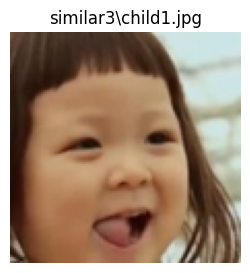

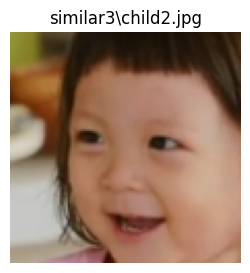

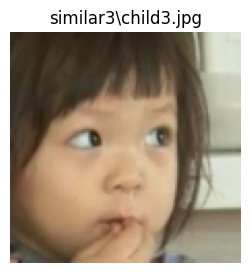

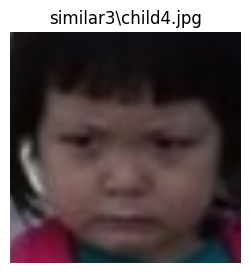

In [97]:
from insightface.utils import face_align
import matplotlib.pyplot as plt

aligned_faces = []

for image_path in image_paths:

    img = cv2.imread(image_path)

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected: {image_path}")
        continue

    face = faces[0]

    aligned = face_align.norm_crop(
        img,
        landmark=face.kps
    )

    aligned_faces.append(aligned)

    plt.figure(figsize=(3,3))
    plt.imshow(
        cv2.cvtColor(
            aligned,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.title(image_path.split("/")[-1])
    plt.axis("off")
    plt.show()

## 3단계: ArcFace 임베딩

In [98]:
import numpy as np
rec_model = app.models["recognition"]

arc_embeddings = []

for aligned in aligned_faces:

    emb = rec_model.get_feat(aligned)

    emb = emb.squeeze()

    emb = emb / np.linalg.norm(emb)

    arc_embeddings.append(emb)

    print(
        emb.shape,
        np.linalg.norm(emb)
    )

(512,) 0.99999994
(512,) 0.99999994
(512,) 1.0
(512,) 1.0


## 4단계 : AdaFace 임베딩

In [99]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

ada_embeddings = []

for aligned in aligned_faces:

    aligned_rgb = cv2.cvtColor(
        aligned,
        cv2.COLOR_BGR2RGB
    )

    img_tensor = torch.tensor(
        aligned_rgb.astype(np.float32) / 255.0
    )

    img_tensor = (img_tensor - 0.5) / 0.5

    img_tensor = img_tensor.permute(2, 0, 1)
    img_tensor = img_tensor.unsqueeze(0)

    with torch.no_grad():
        embedding = F.normalize(
            model(img_tensor),
            p=2,
            dim=1
        )

    embedding = embedding.squeeze().cpu().numpy()

    ada_embeddings.append(embedding)

    print(
        embedding.shape,
        np.linalg.norm(embedding)
    )

(512,) 1.0
(512,) 1.0
(512,) 1.0
(512,) 1.0


## 5단계 : AuraFace 임베딩

In [100]:
import numpy as np
import cv2

aura_embeddings = []

for face_data in all_faces:
    img = face_data["img"]
    face = face_data["face"]
    
    # 1. InsightFace를 이용해 얼굴 정렬 정규화 이미지 추출 (112x112)
    from insightface.utils import face_align
    aligned_img = face_align.norm_crop(img, landmark=face.kps)
    
    # 2. [교정] BGR에서 RGB로 채널 순서 변경
    aligned_rbg = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB)
    
    # 3. [교정] 차원 변경 (H, W, C) -> (C, H, W)
    input_blob = np.transpose(aligned_rbg, (2, 0, 1))
    input_blob = np.expand_dims(input_blob, axis=0).astype(np.float32)
    
    # 4. [교정] 픽셀 값 정규화 (0~255 -> -1~1 스케일 변환)
    # AuraFace(ArcFace 기반) 모델의 표준 전처리 공식입니다.
    input_blob = (input_blob - 127.5) / 127.5
    
    # 5. ONNX 인퍼런스 수행
    outputs = aura_session.run([output_name], {input_name: input_blob})
    raw_embedding = outputs[0][0] # Shape: (512,)
    
    # 6. [교정] 코사인 유사도 계산을 위한 L2 정규화 (Norm을 1로 생성)
    norm = np.linalg.norm(raw_embedding)
    normed_embedding = raw_embedding / norm if norm > 0 else raw_embedding
    
    # [추가] 임베딩 Shape 및 정규화 결과(Norm) 출력
    print(
        normed_embedding.shape,
        np.linalg.norm(normed_embedding)
    )
    
    aura_embeddings.append(normed_embedding)

# 이후 스코어 비교 (Dot Product 수행 시 정상적인 코사인 유사도 값이 나옵니다)
# score = np.dot(aura_embeddings[i], aura_embeddings[j])

(512,) 1.0
(512,) 1.0
(512,) 1.0
(512,) 1.0


## 6단계 : ArcFace 임베딩 결과 상호 비교

In [101]:
for i in range(len(arc_embeddings)):
    for j in range(i+1, len(arc_embeddings)):

        score = np.dot(
            arc_embeddings[i],
            arc_embeddings[j]
        )

        print(
            f"{os.path.basename(image_paths[i])}"
            f" vs "
            f"{os.path.basename(image_paths[j])}"
            f" : {score:.4f}"
        )

child1.jpg vs child2.jpg : 0.6979
child1.jpg vs child3.jpg : 0.6075
child1.jpg vs child4.jpg : 0.5444
child2.jpg vs child3.jpg : 0.6030
child2.jpg vs child4.jpg : 0.5365
child3.jpg vs child4.jpg : 0.5256


## 7단계 : AdaFace 임베딩 결과 상호 비교

In [102]:
for i in range(len(ada_embeddings)):
    for j in range(i+1, len(ada_embeddings)):

        score = np.dot(
            ada_embeddings[i],
            ada_embeddings[j]
        )

        print(
            f"{os.path.basename(image_paths[i])}"
            f" vs "
            f"{os.path.basename(image_paths[j])}"
            f" : {score:.4f}"
        )

child1.jpg vs child2.jpg : 0.6990
child1.jpg vs child3.jpg : 0.5907
child1.jpg vs child4.jpg : 0.5489
child2.jpg vs child3.jpg : 0.6293
child2.jpg vs child4.jpg : 0.5140
child3.jpg vs child4.jpg : 0.5559


## 8단계 : auraFace 임베딩 결과 상호 비교

In [103]:
for i in range(len(aura_embeddings)):
    for j in range(i + 1, len(aura_embeddings)):

        score = np.dot(
            aura_embeddings[i],
            aura_embeddings[j]
        )

        print(
            f"{os.path.basename(image_paths[i])}"
            f" vs "
            f"{os.path.basename(image_paths[j])}"
            f" : {score:.4f}"
        )

child1.jpg vs child2.jpg : 0.6578
child1.jpg vs child3.jpg : 0.5985
child1.jpg vs child4.jpg : 0.4511
child2.jpg vs child3.jpg : 0.5122
child2.jpg vs child4.jpg : 0.4309
child3.jpg vs child4.jpg : 0.4877


## 9단계 : auraFace FaceAnalysis 활용

In [104]:
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(
    name="auraface",
    root=".",
    providers=["CUDAExecutionProvider"]
)

face_app.prepare(ctx_id=0)


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\auraface\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\auraface\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\auraface\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\auraface\glintr100.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: .\models\auraface\scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


In [105]:
from itertools import combinations
embeddings = {}

for image_path in image_paths:
    img = cv2.imread(image_path)

    faces = face_app.get(img)

    if len(faces) == 0:
        print(f"No face found: {image_path}")
        continue

    embeddings[os.path.basename(image_path)] = faces[0].normed_embedding

# 모든 조합 similarity 계산
for img1, img2 in combinations(embeddings.keys(), 2):
    emb1 = embeddings[img1]
    emb2 = embeddings[img2]

    similarity = np.dot(emb1, emb2)

    print(
        f"{img1} vs {img2} : "
        f"{similarity:.4f}"
    )

child1.jpg vs child2.jpg : 0.6578
child1.jpg vs child3.jpg : 0.5985
child1.jpg vs child4.jpg : 0.4511
child2.jpg vs child3.jpg : 0.5122
child2.jpg vs child4.jpg : 0.4309
child3.jpg vs child4.jpg : 0.4877
